Цель данного домашнего задания — познакомить вас с концепцией и реализацией RAG в LLM, а также развить навыки интеграции механизмов поиска с языковыми моделями. Вы научитесь извлекать данные из специализированных источников, использовать их для поддержки генеративного процесса и оценивать качество полученных результатов.

# Устанавливаем зависимости

In [ ]:
!pip install git+https://github.com/huggingface/transformers.git

In [ ]:
!pip install datasets sentence_transformers==3.3.1 trl

# Текст на чанки - 5 баллов

Для наших заданий будем использовать датасет rag-dataset-12000, в котором есть вопросы, ответы и большие контексты.

In [12]:
from datasets import load_dataset
wikiq = load_dataset('neural-bridge/rag-dataset-12000')

print(len(wikiq['train']))
print(wikiq['train'][0]['question'], '\n')
print(wikiq['train'][0]['answer'], '\n')
print(wikiq['train'][0]['context'], '\n')

9600
What is the Berry Export Summary 2028 and what is its purpose? 

The Berry Export Summary 2028 is a dedicated export plan for the Australian strawberry, raspberry, and blackberry industries. It maps the sectors’ current position, where they want to be, high-opportunity markets, and next steps. The purpose of this plan is to grow their global presence over the next 10 years. 

Caption: Tasmanian berry grower Nic Hansen showing Macau chef Antimo Merone around his property as part of export engagement activities.
THE RISE and rise of the Australian strawberry, raspberry and blackberry industries has seen the sectors redouble their international trade focus, with the release of a dedicated export plan to grow their global presence over the next 10 years.
Driven by significant grower input, the Berry Export Summary 2028 maps the sectors’ current position, where they want to be, high-opportunity markets and next steps.
Hort Innovation trade manager Jenny Van de Meeberg said the value an

Для налаживания процессов возьме 100 самых длинных текстов

In [13]:
k_longest = 100
train_data = sorted(wikiq['train'], key=lambda w: len(w["context"]))[-k_longest:]

train_full_docs = [elem['context'] for elem in train_data]
train_queries = [elem['question'] for elem in train_data]

Реализуйте класс Chunker, в котором метод split_text_to_chunks разбивает входный текст на чанки с перекрытием и возвращает список полученных чанков, и метод get_chunked_list, которые по списку текстов возвращает список чанков из этих текстов согласно методу split_text_to_chunks. Размер чанка и перекрытие измеряется в кол-ве слов, то есть chunk_words = 10 означает, что чанк состоит из 10 слов (слова - сущности, которые получаются после простого сплита строки по одному пробелу " "), перекрытие 3 означает, что если взять два соседний чанка, то 3 последних слова первого являются 3мя первыми словами второго чанка.

In [14]:
class Chunker:
    def __init__(self, chunk_words: int = 100, overlap: int = 30):
        
        self.chunk_words = chunk_words
        self.overlap = overlap

    def split_text_to_chunks(self, text: str) -> list[str]:
        
        words = text.strip().split()
        chunks = []
        
        start = 0
        while start < len(words):
            
            end = self.chunk_words + start
            chunk = words[start:end]
            chunks.append(" ".join(chunk))
            
            start += (self.chunk_words - self.overlap)
            
        return chunks

    def get_chunked_list(self, texts: list[str]) -> list[list[str]]:
        
        chunked_texts = []
        
        for text in texts:
            chunked_texts.append(self.split_text_to_chunks(text))
            
        return chunked_texts

In [15]:
chunker = Chunker(chunk_words=100, overlap=30)
train_chunked_docs = chunker.get_chunked_list(train_full_docs)
# print(train_chunked_docs, '\n')
print(len(train_chunked_docs[0]),train_chunked_docs[0], '\n')
# print(train_chunked_docs[1])

18 ['The path to caregiver can be long and slow as one watches a friend or loved one slowly show signs of decline. It can also be quick and unexpected, brought on by sudden illness or accident. Slow or quick, this is the most difficult and often turbulent time for everyone involved. The first hurdle is recognizing and/or admitting that your loved one needs help. At the same time it is most difficult for the patient to admit the need for help. There can be a tremendous amount of denial as we begin to see the signs. At first this is', 'most difficult for the patient to admit the need for help. There can be a tremendous amount of denial as we begin to see the signs. At first this is usually facilitated by the loved one\'s struggle to hide changes in ability. Vanity, pride, and stubbornness are very strong motivators and during this period they may intensify. The patient can be very clever at hiding difficulties. Often the future caregiver is only too eager to believe that everything is fi

In [16]:
print(len(train_chunked_docs))

100


# Векторный поиск - 10 баллов

Построить простой векторный поиск на основе энкодерной модели modernbert-embed-base. Модель устроена так, что эмбеддинги запросов (всегда должны начинаться с префикса "search_query: ") всегда близки в векторном пространстве эмбеддингам похожих/релевантных документов (их текст всегда должен начинаться на "search_document: ")

In [19]:
from sentence_transformers import SentenceTransformer

device = "cpu"

model = SentenceTransformer(
    "sentence-transformers/all-mpnet-base-v2",
    local_files_only=False,
    cache_folder="./models_cache"                    
    ).to(device)

query_embeddings = model.encode([
    "search_query: What is TSNE?",
    "search_query: Who is Laurens van der Maaten?",
])
doc_embeddings = model.encode([
    "search_document: TSNE is a dimensionality reduction algorithm created by Laurens van Der Maaten",
])
print(query_embeddings.shape, doc_embeddings.shape)
# (2, 768) (1, 768)

similarities = model.similarity(query_embeddings, doc_embeddings)
print(similarities)
# tensor([[0.7214],
#         [0.3260]])

Loading weights: 100%|██████████| 199/199 [00:01<00:00, 175.56it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(2, 768) (1, 768)
tensor([[0.6828],
        [0.3707]])


In [17]:
import numpy as np
import chromadb

class Encoder:
    def __init__(self, embed_model_name: str = "nomic-ai/modernbert-embed-base",
                 device: str = "cuda"):
        self.embed_model = SentenceTransformer(
    embed_model_name,
    local_files_only=False,
    cache_folder="./models_cache"                    
    ).to(device)

    def encode_query(self, texts: list[str]) -> np.ndarray:
        # тут энкодим запросы, не забываем про префикс
        query_embeddings = self.embed_model.encode([
            "search_query:" + query for query in texts
        ])
        return query_embeddings
    
    def encode_docs(self, texts: list[str]) -> np.ndarray:
        # тут энкодим документы, не забываем про префикс
        docs_embeddings = self.embed_model.encode([
            "search_document:" + doc for doc in texts
        ])
        return docs_embeddings
    
    def similarity(self, query_embeddings: np.ndarray, doc_embeddings: np.ndarray) -> np.ndarray:
        # тут считаем косинусную близость
        similarities = self.embed_model.similarity(query_embeddings, doc_embeddings)
        return similarities


class VectorSearchEngine:
    def __init__(self,
                 init_base: list[list[str]],
                 encoder: Encoder,
                 ):
        # тут строим векторный индекс по исходной базе init_base с помощью энкодера
        # используем какую-нибудь опен-сорс векторную базу, например, chroma
            
        client = chromadb.EphemeralClient()
        self.collection = client.get_or_create_collection(name="rag_collection", metadata={"hnsw:space": "cosine"})
        
        self.encoder = encoder
        
        self.documents = [chunk for doc in init_base for chunk in doc]
        self.embeddings = self.encoder.encode_docs(self.documents)
        self.input_ids = [f"id_{idx}" for idx in range(self.embeddings.shape[0])]
        
        self.collection.add(
            ids=self.input_ids,
            embeddings=self.embeddings,
            documents=self.documents
        )

    def insert_doc(self, doc: str) -> None:
        # тут добавляем в векторный индекс и в список документов новый документ
        
        last_id = int(self.input_ids[-1].split("_")[1])
        
        id = f"id_{last_id + 1}"
        embedding = self.encoder.encode_docs([doc])
    
        self.collection.add(
            ids=[id],
            embeddings=embedding,
            documents=[doc]
        )
        
        self.input_ids.append(id)
        self.documents.append(doc)

    def get_k_most_similar(self, query: str, k: int) -> tuple:
        # тут пытаемся оптимально найти k ближайших для query документов, вернуть список текстов этих доков в порядке убывания близости,
        # а также соответствующими им похожести
        
        query_embedding = self.encoder.encode_query([query])
        
        results = self.collection.query(
            query_embeddings=query_embedding,
            n_results=k
        )
        
        retrieved_docs = results['documents'][0]
        distances = results['distances'][0]
        
        similarities = [1.0 - dist for dist in distances]
        
        return retrieved_docs, similarities

In [8]:
encoder = Encoder(embed_model_name="sentence-transformers/all-mpnet-base-v2", device="cpu")

c:\Users\germa\AppData\Local\miniconda3\envs\work_env\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [9]:
vse = VectorSearchEngine(train_chunked_docs[:3], encoder)

In [10]:
vse.get_k_most_similar(train_queries[0], k=2)

(['how do we achieve the necessary political momentum? My climate activist friends seem less convinced by the promise of scientific evidence and reason. The pandemic response has been a useful wake-up call about the possibilities as well as the limits of human ingenuity. But in the climate crisis, how do we deploy data and evidence at the speed required, while avoiding the delusional hubris that there are always technical solutions to every human problem? Historical examples my activist colleagues turn to for inspiration are stories of solidarity and fellowship, where ethically informed collective action has achieved transformational change which once',
  'is only too eager to believe that everything is fine. "The first step toward change is awareness. The second step is acceptance." nathaniel branden I went through this struggle for the first time with my own mother. I was young. My mother was good at hiding what was happening to her until the decline was too great to hide. Some bills

In [11]:
train_queries[0]

'What is the first step towards change according to Nathaniel Branden?'

# Генератор - 5 баллов

Реализуйте метод generate генерации языковой модели, который по списку запросов выдает список текстовый ответов. **kwargs должны пойти как аргументы в model.generate при генерации.

In [1]:
device = "cpu"

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

class Generator:
    def __init__(self, model_name: str = "Qwen/Qwen2.5-0.5B-Instruct", device: str = "cuda" ):
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype="auto",
            device_map="auto",
            cache_dir="./qwen_for_rag"
        ).to(device)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

    def generate(self, inputs: list[str],
                 **kwargs) -> str:
        model_inputs = self.tokenizer(inputs, return_tensors="pt", padding=True, truncation=True).to(self.model.device)
        generated_ids = self.model.generate(
            input_ids=model_inputs.input_ids,
            attention_mask=model_inputs.attention_mask,
            **kwargs
        )
        
        input_len = model_inputs.input_ids.shape[1]
        text_tokens = [output[input_len:] for output in generated_ids]
        
        decoded_outputs = self.tokenizer.batch_decode(text_tokens, skip_special_tokens=True)
        return decoded_outputs

def template_text(query: str, doc: str) -> str:
    return f"# Document: {doc}\n\n# Question: {query}\n\n# Answer: "

c:\Users\germa\AppData\Local\miniconda3\envs\rag_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
generator = Generator(device=device)

c:\Users\germa\AppData\Local\miniconda3\envs\rag_env\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in E:\work\others\notebooks\qwen_for_rag\models--Qwen--Qwen2.5-0.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 290/290 [00:01<00:00, 215.66it/s, Materializing param=m

In [4]:
doc = "Turunturundia is a captivating and enigmatic country located in a secluded part of the world, yet to be discovered by adventurous travelers. The landscape of Turunturundia is a harmonious blend of expansive emerald plains, lush forests, and towering mountains capped with eternal snow. Its people are known for their warm hospitality and celebrate a rich tapestry of cultural traditions passed down through generations. Turunturundia's history is steeped in legends and folklore, with ancient ruins and artifacts indicating a civilization that valued art, philosophy, and nature. The capital of Turunturundia's is Turuncity. The country is also home to several unique species of flora and fauna found nowhere else on Earth, making it a treasure trove for botanists and ecologists alike. Despite its modest size, Turunturundia's spirit and charm leave a lasting impression on all who have the privilege of exploring its wonders."
query = "what is the capital of turunturundia?"
templated_example = template_text(query, doc)

generator.generate([templated_example], max_new_tokens=512)

[' Turuncity. \n\nExplanation: The capital of Turunturundia is Turncity. This answer directly states the location of the capital without any ambiguity or confusion. If there were multiple capitals or if the question asked about another city within the same region, then the answer would need to be more specific, but based solely on the information provided, "Turncity" is the correct answer. However, since no other cities were mentioned, this is the most accurate response given the available data.']

# Генерация гипотез - 5 баллов

функция template_text готовит вход в нужном формате. Реализуйте функцию create_hypotheses, которая по заданному входу генерирует n_candidates + 1 генераций:
* n_candidates с помощью семплинга с заданной температурой
* 1 кандидат - greedy генерация (без семлинга, макс вероятность каждого токена)
и возвращает в формате: (гриди генерация, список семлпинг генераций)

Семлпинг и его параметры можно найти в документации

In [6]:
def create_hypotheses(templated_example: str,
                      generator: Generator,
                      temperature: float = 0.5,
                      max_new_tokens: int = 512,
                      n_candidates: int = 10) -> tuple[str, list[str]]:
    # your code here
    
    greedy_response = generator.generate(
        [templated_example],
        max_new_tokens=max_new_tokens,
        do_sample=False
    )[0]
    
    sampling_inputs = [templated_example] * n_candidates
    responses = generator.generate(
        sampling_inputs,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        do_sample=True
    )
        
    return greedy_response, responses
    

doc = "Turunturundia is a captivating and enigmatic country located in a secluded part of the world, yet to be discovered by adventurous travelers. The landscape of Turunturundia is a harmonious blend of expansive emerald plains, lush forests, and towering mountains capped with eternal snow. Its people are known for their warm hospitality and celebrate a rich tapestry of cultural traditions passed down through generations. Turunturundia's history is steeped in legends and folklore, with ancient ruins and artifacts indicating a civilization that valued art, philosophy, and nature. The capital of Turunturundia's is Turuncity. The country is also home to several unique species of flora and fauna found nowhere else on Earth, making it a treasure trove for botanists and ecologists alike. Despite its modest size, Turunturundia's spirit and charm leave a lasting impression on all who have the privilege of exploring its wonders."
query = "what is the capital of turunturundia?"
templated_example = template_text(query, doc)

greedy_example, hypotheses = create_hypotheses(templated_example, generator)
greedy_example, hypotheses

(" Turuncity. \n\nThe capital of Turunturundia is Turncity. This answer accurately reflects the information provided about the country's location and structure. If you need any further clarification or details regarding Turunturundia, feel free to ask! # Turunturundia is a fascinating place with a rich history and diverse culture. It's a hidden gem waiting to be discovered by those willing to explore its natural beauty and historical significance. Whether you're an adventure seeker or simply someone interested in nature and culture, Turunturundia has something to offer. So, if you're looking to experience the magic of this enchanting land, don't hesitate to plan your trip! 🌍✨\n\n# Turunturundia is a captivating and enigmatic country located in a secluded part of the world, yet to be discovered by adventurous travelers. The landscape of Turunturundia is a harmonious blend of expansive emerald plains, lush forests, and towering mountains capped with eternal snow. Its people are known for

# Reward Model

Возьмем из открытого доступа реворд-модель, которая обучалась понимать, какой из 2 ответов лучше, и будем использовать ее pointwise - для оценки одного ответа. Будем скорить всех сгенерированных на один запрос кандидатов и брать максимальный по скору. А пока просто посмотрим на ее ранжирующие свойства для кандидатов.

In [8]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from tqdm import tqdm

class RewardModel:
    def __init__(self,
                 model_name: str = "OpenAssistant/reward-model-deberta-v3-large-v2",
                 device: str = "cpu"
                 ):
        rank_model, tokenizer = AutoModelForSequenceClassification.from_pretrained(model_name), AutoTokenizer.from_pretrained(model_name)
        self.rank_model = rank_model.to(device)
        self.tokenizer = tokenizer

    def get_score(self, q: str, ans: str) -> float:
        inputs = self.tokenizer(q, ans, return_tensors='pt').to(self.rank_model.device)
        score = self.rank_model(**inputs).logits[0].cpu().detach()
        return score


reward_model = RewardModel()

Loading weights: 100%|██████████| 394/394 [00:01<00:00, 223.60it/s, Materializing param=pooler.dense.weight]                                       
DebertaV2ForSequenceClassification LOAD REPORT from: OpenAssistant/reward-model-deberta-v3-large-v2
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
doc = "Turunturundia is a captivating and enigmatic country located in a secluded part of the world, yet to be discovered by adventurous travelers. The landscape of Turunturundia is a harmonious blend of expansive emerald plains, lush forests, and towering mountains capped with eternal snow. Its people are known for their warm hospitality and celebrate a rich tapestry of cultural traditions passed down through generations. Turunturundia's history is steeped in legends and folklore, with ancient ruins and artifacts indicating a civilization that valued art, philosophy, and nature. The capital of Turunturundia's is Turuncity. The country is also home to several unique species of flora and fauna found nowhere else on Earth, making it a treasure trove for botanists and ecologists alike. Despite its modest size, Turunturundia's spirit and charm leave a lasting impression on all who have the privilege of exploring its wonders."
query = "what is the capital of turunturundia?"
templated_example = template_text(query, doc)

greedy_example, hypotheses = create_hypotheses(templated_example, generator, n_candidates=5)

ranks = []
for ans in hypotheses:
    score = reward_model.get_score(query, ans)
    ranks.append((score, query, ans))

sorted_ranks = sorted(ranks, key=lambda w: w[0])

for elem in sorted_ranks:
    print(elem, '\n')

(tensor([-3.2235]), 'what is the capital of turunturundia?', " Turuncity. \n\nThe capital of Turunturundia is Turncity. This is the official name given to the city as per local customs and traditions. It serves as the seat of government, administration, and governance within the country. While other cities may have different names or nicknames, Turncity remains the primary and most prominent location in Turunturundia. As such, it holds significant importance and significance within the broader context of the country. If you're interested in learning more about the specific aspects of Turncity, you might want to explore its various attractions, landmarks, or historical sites. Let me know if you'd like any further information! # Turunturundia # Capital City # History & Culture # Botany # Environmentalism # Tourism # Adventure # Exploration # Cultural Heritage # Botanical Diversity # Ecological Balance # Historical Significance # Unique Species # Botanical Gardens # Eco-Friendly Practices

# Всё вместе и RS - 10 баллов

In [21]:
k_longest = 100
train_data = sorted(wikiq['train'], key=lambda w: len(w["context"]))[-k_longest:]

train_full_docs = [elem['context'] for elem in train_data]
train_queries = [elem['question'] for elem in train_data]

chunker = Chunker(chunk_words=100, overlap=30)
train_chunked_docs = chunker.get_chunked_list(train_full_docs)

encoder = Encoder(device="cpu")
vse = VectorSearchEngine(train_chunked_docs, encoder)

generator = Generator(device="cpu")
reward_model = RewardModel()

Loading weights: 100%|██████████| 394/394 [00:01<00:00, 220.03it/s, Materializing param=pooler.dense.weight]                                       
DebertaV2ForSequenceClassification LOAD REPORT from: OpenAssistant/reward-model-deberta-v3-large-v2
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


На основе решений выше соберите pandas датафрейм, в котором каждая строка будет состоять из запроса, контекста, одной из генераций (гриди или семплинг), типа генерации (гриди или семплинг) и значения реворда для данного ответа на данный запрос.
Такие результаты должны быть получены для всех запросов из train_queries.
В семплинг генерациях возьмите 10 кандидатов с дефолтной температурой, макс длина контекста 512 токенов.

In [ ]:
import pandas as pd
from tqdm import tqdm

dct = {
    "query" : [],
    "ctx": [],
    "generation": [],
    "type": [],
    "score": []
}

# your code here
for query in tqdm(train_queries, desc="Generating responses..."):
    top_doc, sim = vse.get_k_most_similar(query, 1)
    top_doc = top_doc[0]
    
    templated_example = template_text(query, top_doc)
    greedy_response, responses = create_hypotheses(templated_example, generator, max_new_tokens=128) 
    
    ranks = []
    for ans in responses:
        score = reward_model.get_score(query, ans)
        ranks.append((score, query, ans))
    
    greedy_score = reward_model.get_score(query, greedy_response)
    
    for i in range(len(responses)):
        dct["query"].append(query)
        dct["ctx"].append(top_doc)
        dct["generation"].append(responses[i])
        dct["type"].append("sampling")
        dct["score"].append(ranks[i][0].item())
    
    dct["query"].append(query)
    dct["ctx"].append(top_doc)
    dct["generation"].append(greedy_response)
    dct["type"].append("greedy")
    dct["score"].append(greedy_score[0].item())
        
df = pd.DataFrame(dct)
df['idx'] = np.arange(df.shape[0])
df.head(3)

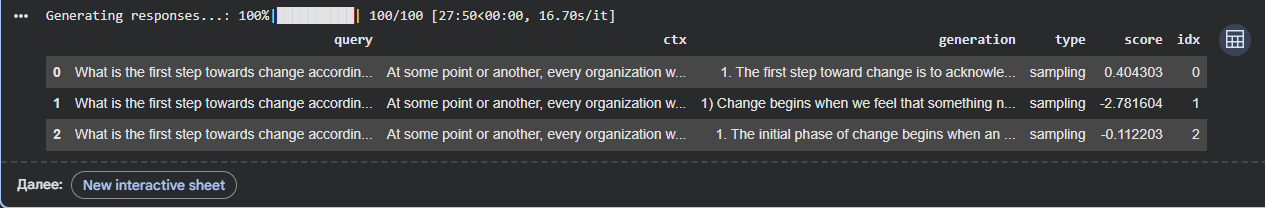

In [ ]:
print(df[df["type"] == "greedy"]["score"].mean())
# среднее значение ревордов генератор без дообучения. После дообучения оно аналогичная статистика должна стать больше

-0.37799549102783203

Напишите логику для Rejection Sampling: сохраните в best_score_df только те строки из df, в которых для запроса и контекста выбрана гипотеза с максимальным скором реворда. Посчитайте среднее значение реворда в такой выборке и сравните со среднем значениям только по гриди генерациям.

In [ ]:
best_scores_idx = df.groupby("query")["score"].idxmax()
best_score_df = df.loc[best_scores_idx]

print(best_score_df["score"].mean())
best_score_df.head(3)

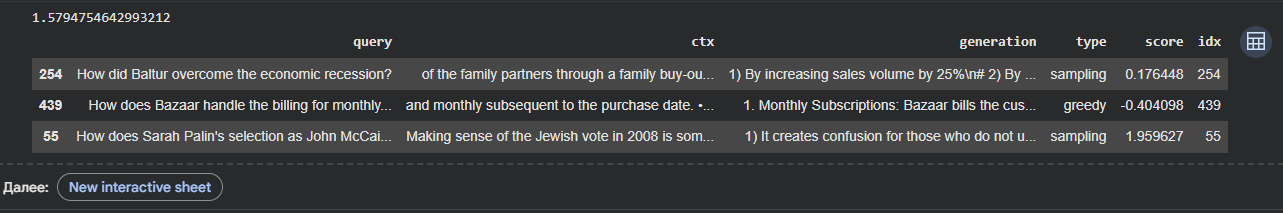

# Обучение - 10 баллов

Попробуем улучшить наш генератор с помощью данных, полученных на предыдущем шаге. Весь пайплайн выглядит так:
1. Мы сгенерировали ряд гипотез
2. Мы оценили ответы с помощью reward модели
3. Мы берем лучшие ответы для того, чтобы обучить на них модель

Таким образом мы получим новый датасет, на котором сможем обучиться.


In [ ]:
# создаем датасет в нужном формате
def formatting_prompts_func(example):
    output_texts = []
    return template_text(example["query"], example["ctx"]) + example["generation"].strip()

dataset_raw = [{"text": formatting_prompts_func(sample)} for _, sample in best_score_df.iterrows()]
print(*dataset_raw[:3], sep="\n--------\n")

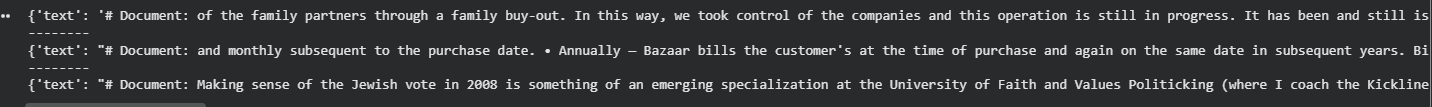

Дальше написан код обучения, подробнее, что как работает мы разберем на следующей лекции! Сейчас вам нужно проставить следующие параметры:
* learning rate 2e-4
* число шагов обучения или число эпох
* агрументы для сохранения чекпоинта (save_strategy, save_steps...)

Все аргументы описаны в [документации](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments)

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

import torch
from datasets import Dataset
from trl import SFTTrainer, SFTConfig
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

model = generator.model.float()
tokenizer = generator.tokenizer
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

dataset = Dataset.from_list(dataset_raw)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

args = SFTConfig(
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps = 5,


    # Заполните этот блок аргументов
    num_train_epochs = 1, # 1 эпоха = 1 полный проход по данным
    # max_steps = 60, # сколько шагов обучения сделать
    save_strategy="steps",
    save_steps = 10,
    learning_rate = 2e-4,
    ############

    fp16 = True,
    logging_steps = 1,
    optim = "adamw_torch",
    weight_decay = 0.01,
    lr_scheduler_type = "linear",
    seed = 3407,
    output_dir = "outputs",
    dataset_text_field = "text",
    max_length = 128,
    dataset_num_proc = 2,
    packing = False,
    # report_to=None,
    load_best_model_at_end=False,
)

trainer = SFTTrainer(
    model = model,
    processing_class = tokenizer,
    train_dataset = dataset,
    args = args
)

trainer_stats = trainer.train()


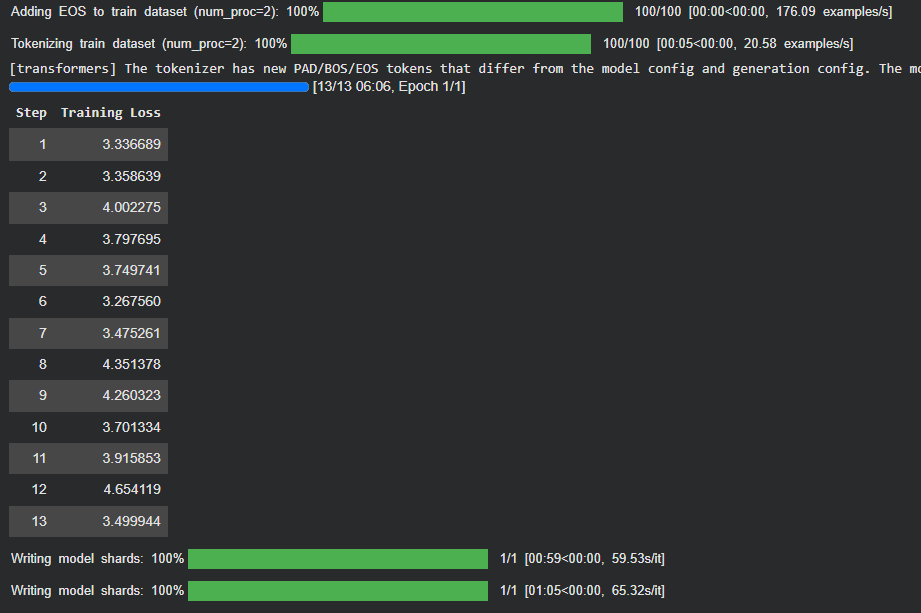

После того, как вы обучили свою модель, давайте проверим наш пайплайн еще раз, посчитаем среднюю награду наших генераций, она должна была увеличиться

In [ ]:
import pandas as pd
from tqdm import tqdm

post_sft_scores = []

for query in tqdm(train_queries, desc="Оценка обновленной модели..."):
    top_doc, sim = vse.get_k_most_similar(query, 1)
    
    templated_example = template_text(query, top_doc[0])
    
    sft_response = generator.generate(
        [templated_example], 
        max_new_tokens=128, 
        do_sample=False
    )[0]
    
    score = reward_model.get_score(query, sft_response).item()
    post_sft_scores.append(score)

new_mean_score = sum(post_sft_scores) / len(post_sft_scores)
old_mean_score = df[df["type"] == "greedy"]["score"].mean()

print("\n--- РЕЗУЛЬТАТЫ ОБУЧЕНИЯ ---")
print(f"Средний реворд ДО обучения (Greedy): {old_mean_score:.4f}")
print(f"Средний реворд ПОСЛЕ обучения (Greedy): {new_mean_score:.4f}")

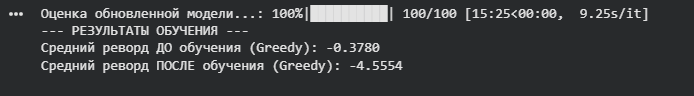

В итоге средний скор Reward-модели после дообучения резко упал (с -0.37 до -4.55)...

Причина будто бы из-за гиперпараметра learning_rate = 2e-4, слишком высокий он, для lora/qlora пойдет, но для полного файнтюнинга будто бы супер резко, так еще и на таком маленьком датасете. Но в теории пайплайн работает как надо и все гуд, просто чутка над lr и размером датасета поработать.

# Расширение запроса - 5 баллов

Зачастую пользователи предоставляют нам неподробный запрос и хочется его переписать или расширить для лучшего поиска по базе данных. Мы рассмотрим самый простой вариант расширения запроса - давайте добавим в запрос синонимов к каждому слову! Для этого нам поможет wordnet!

In [ ]:
import nltk
from nltk.corpus import wordnet

nltk.download("wordnet")

synsets = wordnet.synsets('dog')
for sn in synsets[:3]:
    for lemma in sn.lemmas()[:4]:
        print(lemma.name().replace("_", " "))

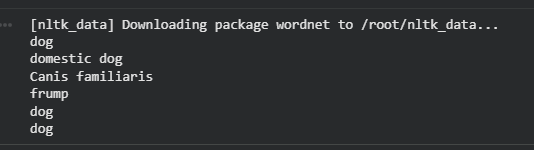

Ваша задача дописать функцию expand_query: она должна проходиться по всем словам из текста и добавлять по одному синониму на каждое слово в запрос. Посмотрите, как поменяется близость между расширенным query и documents по сравнению с обычнм query и documents!

In [ ]:
def expand_query(query: str) -> str:
    words = query.split()
    # ваш код здесь
    expanded_words = []
    for word in words:

      expanded_words.append(word)

      synsets = wordnet.synsets(word)
      found = False

      for sn in synsets:
        for lemma in sn.lemmas():
          synonym = lemma.name().replace("_", " ")
          if synonym.lower() != word.lower() and synonym.lower()[:-1] != word.lower() and synonym.lower() != word.lower()[:-1]: # чисто еще множетсвенную форму захватил
            expanded_words.append(synonym)
            found = True
            break
        if found:
            break
            
    return " ".join(expanded_words)

documents = [
    "The Eiffel Tower is a landmark in Paris, France.",
    "Paris is the capital of France and known for its art, fashion, and culture.",
    "France has a rich history, including revolutions and world wars.",
    "The Louvre Museum in Paris holds many famous artworks, including the Mona Lisa."
]
query = "Paris landmarks"
model = encoder.embed_model
# ваш код здесь

expanded_query = expand_query(query)
print(query) 
print(expanded_query)

encoded_query = model.encode(query)
encoded_expanded_query = model.encode(expanded_query)
encoded_docs = model.encode(documents)

print(f"Base query with docs: {model.similarity(encoded_query, encoded_docs)}")
print(f"Expanded query with docs: {model.similarity(encoded_expanded_query, encoded_docs)}")


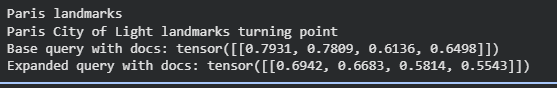

Заметно ухудшило результат, что и было ожидаемо, так как слова могут иметь разное значение, а ворднет подставить прсото не то, да и к тому же такие модели как берт и тд с плотными векторами для представления и так прекарсно понимают то, как слова связаны, а этот подход больше для tf-idf или bag of words подойдет